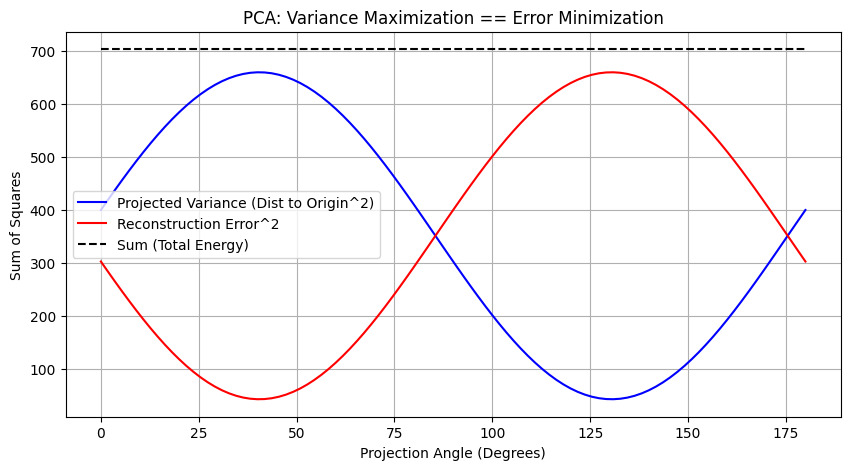

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. 가상 데이터 생성 (평균 중심화 필수)
np.random.seed(42)
X = np.random.randn(100, 2) @ np.array([[2, 1], [1, 1.5]])
X -= X.mean(axis=0)

# 원점으로부터 원본 샘플까지의 거리 제곱합 (고정값)
orig_dist_sq = np.sum(X**2)

angles = np.linspace(0, np.pi, 100)
variances = []
reconst_errors = []

# 2. 임의의 회전 축으로 투영하며 값 측정
for angle in angles:
    # 단위 투영 벡터 w
    w = np.array([np.cos(angle), np.sin(angle)])

    # 투영된 점들의 거리 제곱합 (분산)
    projected = X @ w
    var = np.var(projected) * len(X) # 원점 기준 거리 제곱합과 비례

    # 복원 오차 제곱합
    reconstruction = np.outer(projected, w)
    error = np.sum((X - reconstruction)**2)

    variances.append(var)
    reconst_errors.append(error)

# 3. 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(np.degrees(angles), variances, label='Projected Variance (Dist to Origin^2)', color='blue')
plt.plot(np.degrees(angles), reconst_errors, label='Reconstruction Error^2', color='red')
plt.plot(np.degrees(angles), np.array(variances) + np.array(reconst_errors),
         label='Sum (Total Energy)', linestyle='--', color='black')
plt.title("PCA: Variance Maximization == Error Minimization")
plt.xlabel("Projection Angle (Degrees)")
plt.ylabel("Sum of Squares")
plt.legend()
plt.grid(True)
plt.show()